Nama : Lusia Clara Sianturi

NIM : 2304010019

# Data Classification

**Latar Belakang Dataset**

Dataset Adult Income (Census Income) berasal dari data sensus penduduk yang digunakan untuk menganalisis kondisi sosial ekonomi masyarakat. Dataset ini digunakan untuk memprediksi tingkat pendapatan individu.

**Permasalahan utama dalam dataset ini adalah:**

Bagaimana mengklasifikasikan apakah seseorang memiliki pendapatan tinggi atau rendah berdasarkan karakteristik demografis dan pekerjaan?

**Tujuan Analisis**
- Mengklasifikasikan individu ke dalam kategori: pendapatan rendah (<=50k)
pendapatan tinggi >50k).
- Mengidentifikasi faktor-faktor yang mempengaruhi tingkat pendapatan.
- Membandingkan performa beberapa algoritma machine learning.

**Deskripsi Variabel**

**Variabel Numerik**

- age → umur individu
- fnlwgt → bobot populasi (sampling weight)
- education-num → jumlah tahun pendidikan
- capital-gain → keuntungan investasi
- capital-loss → kerugian investasi
- hours-per-week → jam kerja per minggu

**Variabel Kategorikal**
- workclass → jenis pekerjaan
- education → tingkat pendidikan
- marital-status → status pernikahan
- occupation → jenis pekerjaan spesifik
- relationship → hubungan dalam keluarga
- race → ras
- sex → jenis kelamin
- native-country → negara asal
- income → pendapatan

**Variabel Terget**

income
<=50k → kelas 0, >50k → kelas 1

Ini adalah variabel yang akan dirediksi oleh model.

##**Import Library**

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import GridSearchCV

import warnings
warnings.filterwarnings('ignore')

## **Load Data**

In [36]:
df = pd.read_csv('/content/adult.csv')

# Rapikan nama kolom
df.columns = df.columns.str.strip().str.lower()

print("Info Data:")
df.info()

Info Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


Pada tahap ini dilakukan pemanggilan dataset. Berdasarkan output df.info(), dataset Adult Income terdiri dari 32.561 observasi dan 15 variabel, dengan kombinasi tipe data numerik dan kategorikal.

## **Data Cleaning**

In [37]:
# Replace '?' jadi NaN
df = df.replace('?', np.nan)

# Drop missing value
df = df.dropna()

print("Missing Value Setelah Cleaning:")
print(df.isnull().sum())

Missing Value Setelah Cleaning:
age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64


Pada dataset awal terdapat nilai “?” yang merepresentasikan missing value pada beberapa kolom kategorikal seperti workclass, occupation, dan native.country. Nilai tersebut diubah menjadi NaN dan dilakukan proses cleaning dengan menghapus baris yang mengandung missing value, sehingga setelah proses pembersihan tidak terdapat lagi data kosong dalam dataset.

## **Visualisasi Distribusi Target**

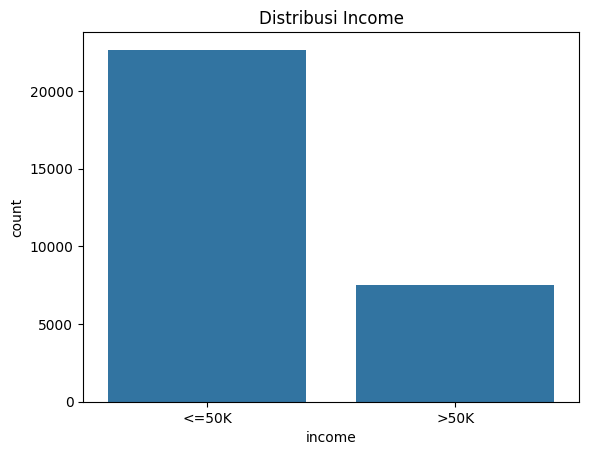

income
<=50K    0.751078
>50K     0.248922
Name: proportion, dtype: float64


In [38]:
plt.figure()
sns.countplot(x='income', data=df)
plt.title('Distribusi Income')
plt.show()

print(df['income'].value_counts(normalize=True))

Grafik menunjukkan distribusi kelas income. Distribusi ini menunjukkan dataset tidak seimbang (imbalanced), dimana mayoritas individu berada pada kategori pendapatan <=50k. Kondisi ini akan membuat model cenderung bias ke kelas mayoritas, serta recall untuk kelas minoritas (>50k) biasanya lebih rendah.

## **Visualisasi Distribusi Numerik**

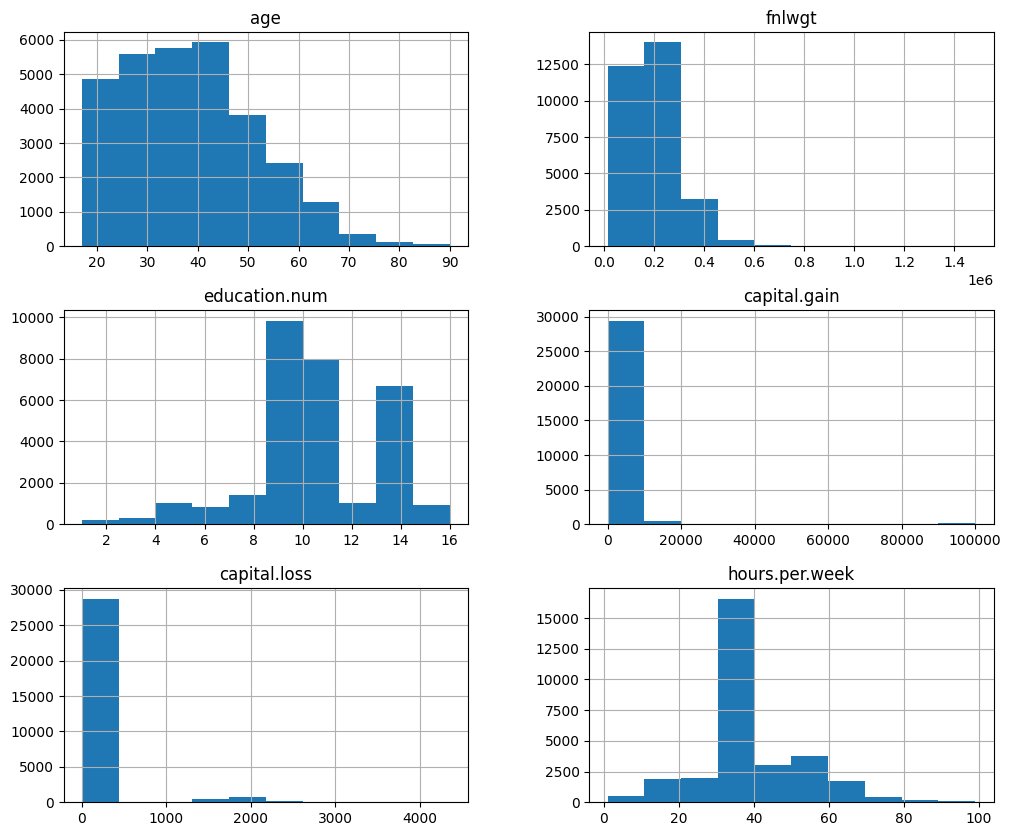

In [39]:
df.hist(figsize=(12,10))
plt.show()

Histogram menunjukkan distribusi setiap variabel numerik. Terlihat bahwa:

- Age → cenderung normal namun sedikit skewed ke kanan (lebih banyak usia produktif)
- fnlwgt → sangat skewed menunjukkan distribusi sampling weight yang tidak merata
- capital.gain & capital.loss → sangat skewed (banyak nilai 0)
- hours.per.week → terkonsentrasi di sekitar 40 jam (full-time).

Ini menunjukkan bahwa variabel tidak berdistribusi normal dan mengandung nilai ekstrem (outlier).

## **Deteksi Outlier**

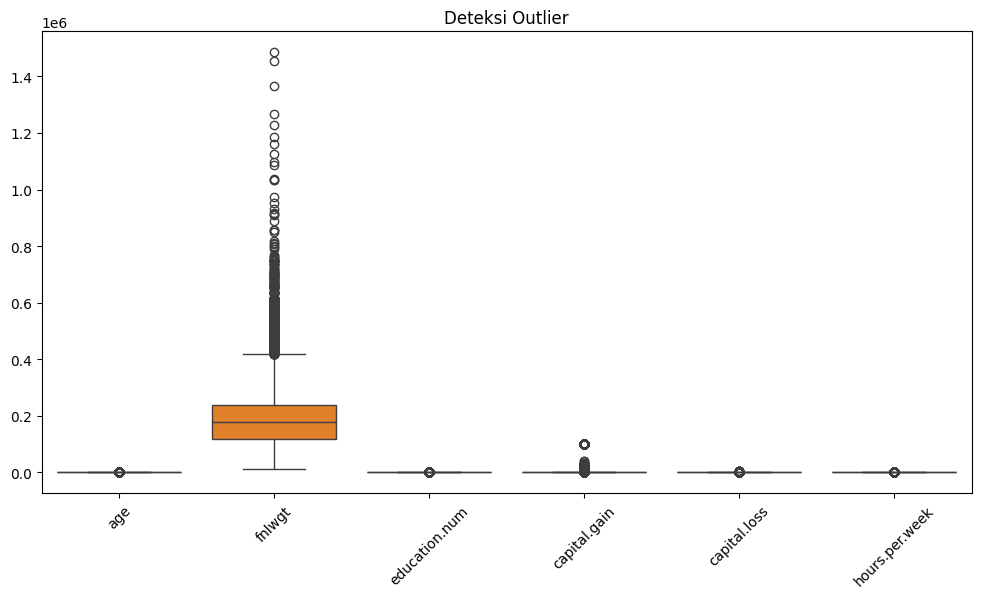

In [40]:
num_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(12,6))
sns.boxplot(data=df[num_cols])
plt.xticks(rotation=45)
plt.title('Deteksi Outlier')
plt.show()

Terdapat outlier pada beberapa variabel numerik seperti fnlwgt, capital gain, capital loss, dan sebagian kecil pada hours per week. Outlier ini tidak dihapus karena dianggap merepresentasikan kondisi nyata dalam data.

## **Analisis Predictor Feature**

### **Boxplot vs Target**

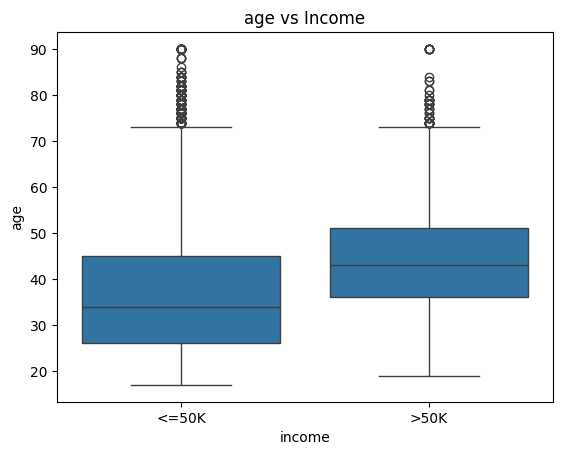

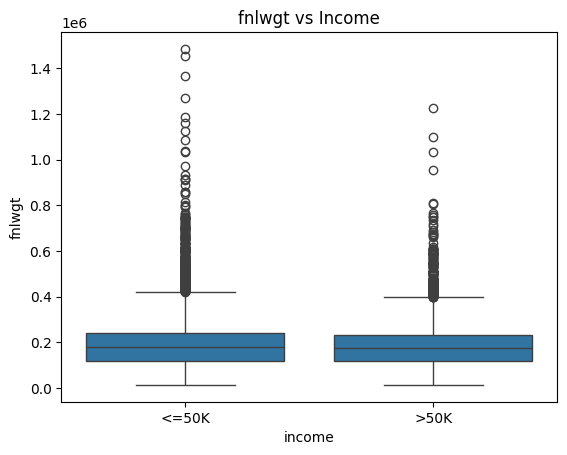

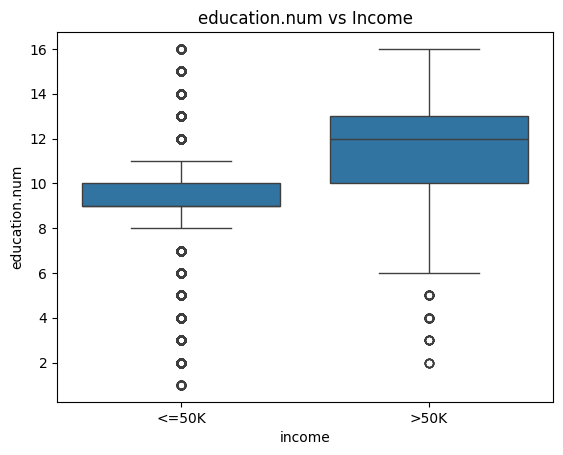

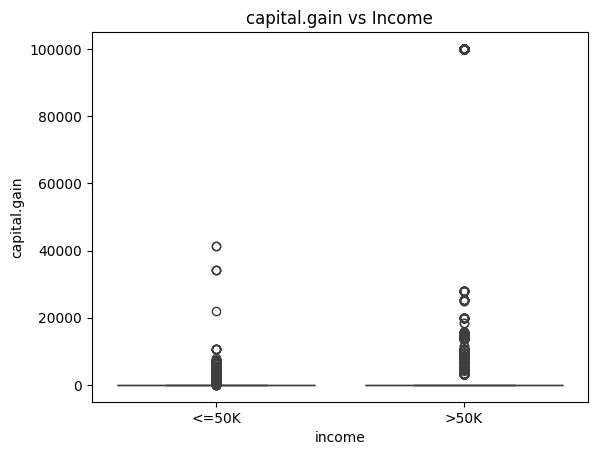

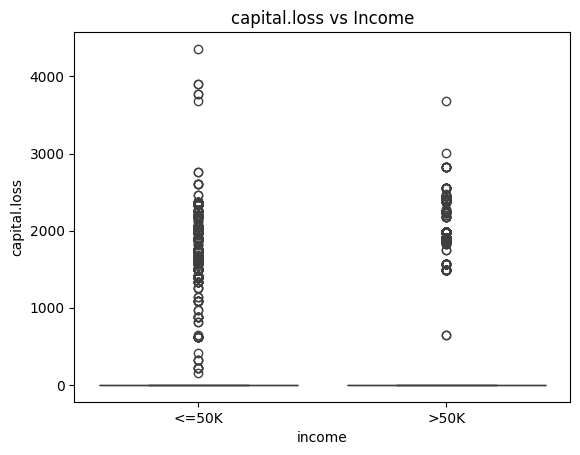

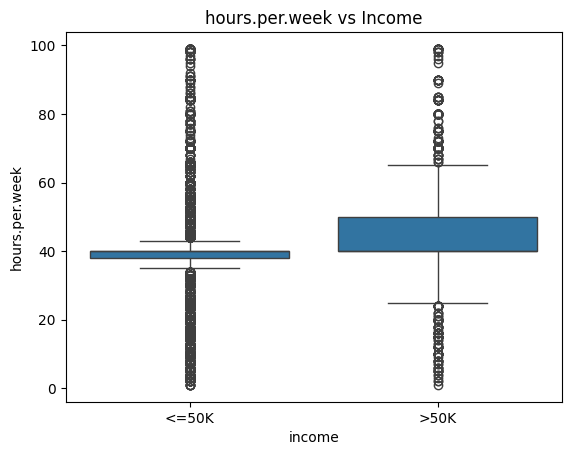

In [41]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x='income', y=col, data=df)
    plt.title(f'{col} vs Income')
    plt.show()

Visualisasi boxplot menunjukkan bahwa variabel seperti age, capital gain, dan education.num memiliki perbedaan distribusi yang cukup jelas antara kelompok income ≤50K dan >50K. Hal ini mengindikasikan bahwa variabel tersebut berpotensi menjadi prediktor penting.

## **Korelasi**

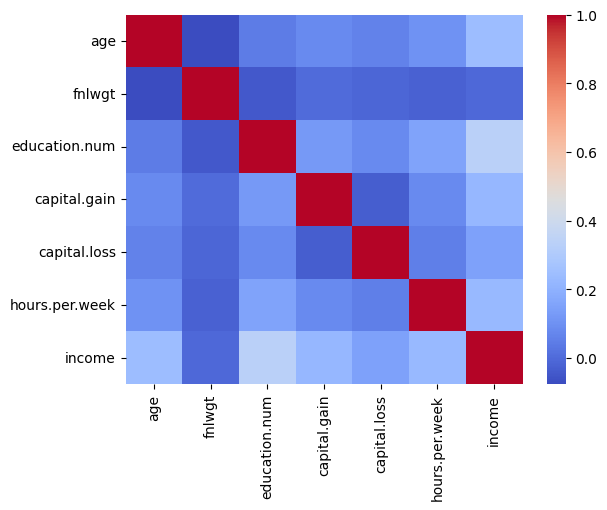

In [42]:
df_corr = df.copy()
df_corr['income'] = df_corr['income'].map({'<=50K':0, '>50K':1})

corr = df_corr.corr(numeric_only=True)

sns.heatmap(corr, cmap='coolwarm')
plt.show()

Hasil korelasi menunjukkan bahwa hubungan antar variabel dengan income cenderung rendah hingga sedang, sehingga pola hubungan tidak sepenuhnya linear. Hal ini diperkuat oleh hasil feature importance dari Random Forest yang menunjukkan bahwa capital gain, age, education merupakan fitur yang paling berpengaruh.

## **Feature Importance**

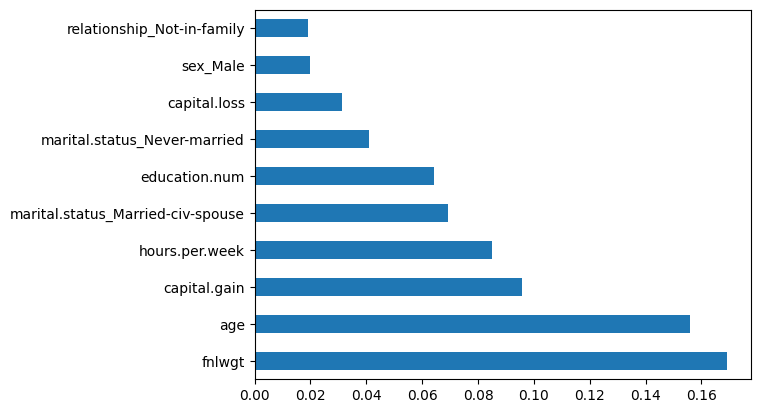

In [43]:
df_enc = pd.get_dummies(df, drop_first=True)

X = df_enc.drop('income_>50K', axis=1)
y = df_enc['income_>50K']

rf = RandomForestClassifier()
rf.fit(X, y)

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.nlargest(10).plot(kind='barh')
plt.show()

Feature importance menunjukkan variabel yang paling berpengaruh dalam model.

Fitur paling berpengaruh adalah: fnlwgt, age, capital gain, relationship, education.num.

## **Split Data**

In [44]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42)

Data dibagi menjadi data training dan testing. Scalling dilakukan agar model seperti KNN dan Logistic Regression bekerja optimal.

## **Modeling**

In [45]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    results.append([name, acc, rec, roc])

    print(f"\n{name}")
    print(classification_report(y_test, y_pred))


Logistic Regression
              precision    recall  f1-score   support

       False       0.88      0.93      0.91      4531
        True       0.75      0.62      0.68      1502

    accuracy                           0.85      6033
   macro avg       0.82      0.78      0.79      6033
weighted avg       0.85      0.85      0.85      6033


KNN
              precision    recall  f1-score   support

       False       0.87      0.90      0.89      4531
        True       0.67      0.60      0.63      1502

    accuracy                           0.83      6033
   macro avg       0.77      0.75      0.76      6033
weighted avg       0.82      0.83      0.82      6033


Naive Bayes
              precision    recall  f1-score   support

       False       0.97      0.41      0.58      4531
        True       0.35      0.96      0.52      1502

    accuracy                           0.55      6033
   macro avg       0.66      0.69      0.55      6033
weighted avg       0.82      0.55  

Pada tahap modeling, **Random Forest** memberikan performa terbaik dibandingkan model lainnya karena mampu menangkap pola kompleks pada data. **Logistic Regression** dan **KNN** menunjukkan performa yang cukup baik, namun masih kalah dalam mendeteksi kelas minoritas. **Naive Bayes** memiliki performa paling rendah karena asumsi independensi variabel tidak terpenuhi, sedangkan Decision Tree cukup baik namun kurang stabil.

## **Confusion Matrix Random Forest**

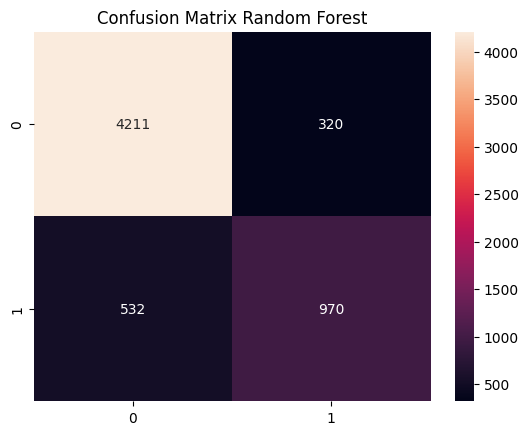

In [46]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='g')
plt.title('Confusion Matrix Random Forest')
plt.show()

Confusion matrix Random Forest menunjukkan bahwa sebagian besar data berhasil diklasifikasikan dengan benar, meskipun masih terdapat kesalahan pada kelas minoritas.

## **Perbandingan Model**

In [30]:
result_df = pd.DataFrame(results, columns=['Model','Accuracy','Precision','Recall','F1','ROC-AUC'])
print(result_df.sort_values(by='ROC-AUC', ascending=False))

                 Model  Accuracy  Precision    Recall        F1   ROC-AUC
3        Random Forest  0.855520   0.740230  0.616071  0.672468  0.902672
0  Logistic Regression  0.826808   0.722672  0.455357  0.558685  0.854773
2          Naive Bayes  0.802702   0.685940  0.332908  0.448261  0.853782
1                  KNN  0.826194   0.660530  0.572066  0.613124  0.847305
4        Decision Tree  0.805312   0.595908  0.594388  0.595147  0.733291


Random Forest memiliki performa paling stabil dengan nilai ROC-AUC tertinggi.

## **Visualisasi Perbandingan Model**

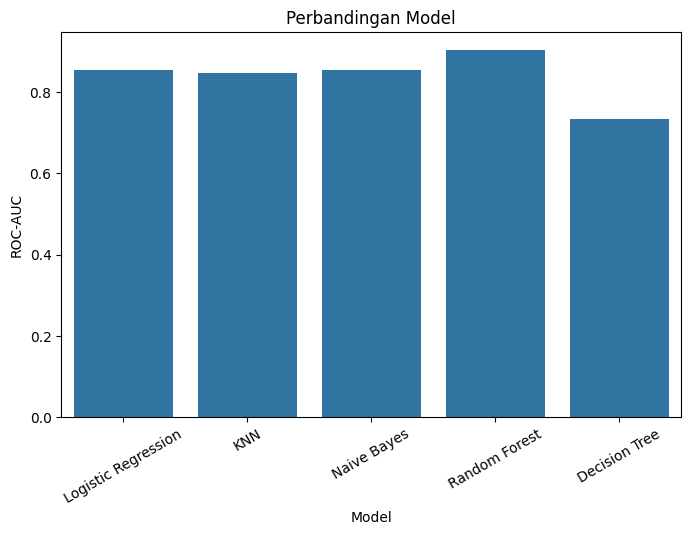

In [31]:
plt.figure(figsize=(8,5))
sns.barplot(x='Model', y='ROC-AUC', data=result_df)
plt.title('Perbandingan Model')
plt.xticks(rotation=30)
plt.show()

## **ROC Curve (Random forest)**

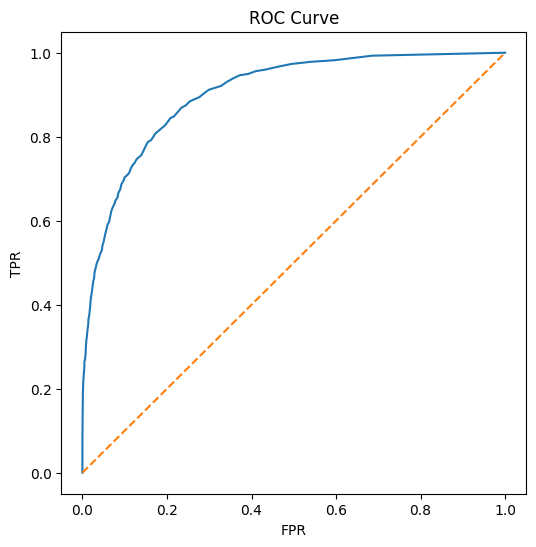

In [32]:
from sklearn.metrics import roc_curve

model = RandomForestClassifier()
model.fit(X_train, y_train)

y_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title('ROC Curve')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.show()

## **Oversampling**

In [48]:
smote = SMOTE()
X_res, y_res = smote.fit_resample(X_train, y_train)

rf.fit(X_res, y_res)
y_pred = rf.predict(X_test)

print("SMOTE Result")
print(classification_report(y_test, y_pred))

SMOTE Result
              precision    recall  f1-score   support

       False       0.90      0.89      0.90      4531
        True       0.68      0.71      0.70      1502

    accuracy                           0.84      6033
   macro avg       0.79      0.80      0.80      6033
weighted avg       0.85      0.84      0.85      6033



## **Undersampling**

In [49]:
rus = RandomUnderSampler()
X_res, y_res = rus.fit_resample(X_train, y_train)

rf.fit(X_res, y_res)
y_pred = rf.predict(X_test)

print("Undersampling Result")
print(classification_report(y_test, y_pred))

Undersampling Result
              precision    recall  f1-score   support

       False       0.94      0.81      0.87      4531
        True       0.60      0.84      0.70      1502

    accuracy                           0.82      6033
   macro avg       0.77      0.83      0.78      6033
weighted avg       0.85      0.82      0.83      6033



Pada **oversampling**, model menjadi lebih seimbang dengan recall kelas minoritas meningkat (0.71) dan akurasi tetap baik (0.84), sehingga mampu mendeteksi lebih banyak data penting tanpa banyak menurunkan performa.

Pada **undersampling**, recall kelas minoritas meningkat lebih tinggi (0.84), namun precision menurun dan akurasi turun (0.82), karena sebagian data mayoritas dihapus.

Sehingga Oversampling lebih stabil, sedangkan Undersampling lebih agresif dalam mendeteksi kelas minoritas tetapi lebih berisiko error.


## **Hyperparameter Tuning**

In [50]:
param_grid = {
    'n_estimators':[100,200],
    'max_depth':[None,10],
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3, scoring='roc_auc')
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

Best Params: {'max_depth': 10, 'n_estimators': 200}


Melalui hyperparameter tuning, performa Random Forest dapat ditingkatkan dengan kombinasi parameter yang optimal, terutama dalam meningkatkan nilai ROC-AUC. Secara keseluruhan, Random Forest menjadi model terbaik karena memiliki akurasi tinggi, stabil, dan mampu menangani kompleksitas data dengan baik.

## **Evaluasi Model Terbaik**

In [51]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

       False       0.87      0.96      0.91      4531
        True       0.82      0.56      0.66      1502

    accuracy                           0.86      6033
   macro avg       0.84      0.76      0.79      6033
weighted avg       0.86      0.86      0.85      6033

ROC-AUC: 0.9183725752553573


Model memiliki akurasi tinggi (0.86) dan sangat baik dalam mengenali kelas mayoritas (recall 0.96). Namun, pada kelas minoritas, recall masih rendah (0.56), sehingga sebagian data belum terdeteksi. Nilai ROC-AUC 0.918 menunjukkan model sudah sangat baik dalam membedakan kedua kelas, tetapi masih perlu peningkatan pada deteksi kelas minoritas.

## **Kesimpulan**

Secara keseluruhan, model Random Forest merupakan model terbaik dalam memprediksi income karena mampu menangkap hubungan non-linear antar variabel. Ketidakseimbangan data menjadi tantangan utama, namun dapat diatasi dengan teknik seperti SMOTE. Variabel seperti age, capital gain, dan education menjadi faktor utama dalam menentukan tingkat pendapatan individu.

In [52]:
import pickle

filename = '/content/random_forest_model'

with open(filename, 'wb') as file:
    pickle.dump(best_model, file)

print("Model berhasil disimpan di Colab!")

Model berhasil disimpan di Colab!
